In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip freeze > '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/rf_energia_eolica__requirements.txt'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import numpy as np
import folium
import time

In [ ]:
# --- Etapa 1: Carregar Dados e Engenharia de Atributos ---
print("--- Iniciando Etapa 1: Preparação dos Dados para Regressão ---")
try:
    df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/FACT_LOCALIDADE_CLIMA_202509272358.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'FACT_LOCALIDADE_CLIMA_202509272358.csv' não encontrado.")
    exit()
# Passando os nomes das colunas para minúsculas (lowercase)
df_train.columns = [col.replace('"', '').lower() for col in df_train.columns]

# Remove dados faltantes (NaN)
print("\nLimpando dados faltantes no arquivo de treino.")
df_train.dropna(inplace=True)
print("Limpeza do arquivo de treino concluída.")


--- Iniciando Etapa 1: Preparação dos Dados para Regressão ---

Limpando dados faltantes no arquivo de treino.
Limpeza do arquivo de treino concluída.


In [ ]:
# --- Etapa 2: Treinamento do Modelo de Regrassão usando Grid Search ---

print("\n--- Iniciando Etapa 2: Treinamento do Modelo de Regressão e Otimização com Grid Search nos dados aeicionados ---")

# Adiciona as novas features baseadas em data
df_train['data'] = pd.to_datetime(df_train['data'])
df_train['mes'] = df_train['data'].dt.month
df_train['dia_do_ano'] = df_train['data'].dt.dayofyear
print("Novos atributos 'mes' e 'dia_do_ano' criados.")

# Aqui foi definida a variável alvo e as variáveis de entrada (features)
target = 'wind_speed_10m_mean'
features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'relative_humidity_2m_mean', 'surface_pressure_mean', 'wind_speed_10m_max',
    'shortwave_radiation_sum', 'precipitation_sum', 'mes', 'dia_do_ano'
]

# Features que serão usadas
print("\nFeatures que serão usadas no modelo:")
print(features)


X = df_train[features]
y = df_train[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Define a grade de parâmetros para testar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

# Configura e executa o Grid Search
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Busca os melhores hiperparâmetros. Isso demora.")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"Grid Search concluído em {(end_time - start_time):.2f} segundos.")

# Aqui guarda o melhor modelo encontrado
best_rf_model = grid_search.best_estimator_
print("\nMelhores parâmetros encontrados:")
print(grid_search.best_params_)


y_pred = best_rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nResultados da Avaliação do Modelo:")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {np.sqrt(mse):.4f}")


--- Iniciando Etapa 2: Treinamento do Modelo de Regressão e Otimização com Grid Search nos dados aeicionados ---
Novos atributos 'mes' e 'dia_do_ano' criados.

Features que serão usadas no modelo:
['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'wind_speed_10m_max', 'shortwave_radiation_sum', 'precipitation_sum', 'mes', 'dia_do_ano']
Busca os melhores hiperparâmetros. Isso demora.
Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Grid Search concluído em 2145.52 segundos.

Melhores parâmetros encontrados:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}

Resultados da Avaliação do Modelo:
R² (Coeficiente de Determinação): 0.9448
MSE (Erro Quadrático Médio): 2.0204
RMSE (Raiz do Erro Quadrático Médio): 1.4214


In [ ]:
# --- Etapa 3: Salva o Modelo Treinado e Otimizado ---
print("\n--- Iniciando Etapa 3: Salvando o Modelo de Regressão ---")
model_filename_final = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/random_forest_eolica_otimizado.joblib'
joblib.dump(best_rf_model, model_filename_final)
print(f"Modelo salvo com sucesso no arquivo: {model_filename_final}")


--- Iniciando Etapa 3: Salvando o Modelo de Regressão ---
Modelo salvo com sucesso no arquivo: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/random_forest_eolica_otimizado.joblib


In [ ]:
# --- Etapa 4: Usando o Modelo para Prever o Potencial Solar ---
print("\n--- Iniciando Etapa 4: Prevendo a Velocidade do Vento para Goiás ---")
try:
    df_goias = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/goias_clima_era5_diario_completo.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'goias_clima_era5_diario_completo.csv' não encontrado.")
    exit()

# Limpeza de dados faltantes no arquivo de Goiás, se houvercaso existam
if df_goias[features[:-2]].isnull().sum().any():
    df_goias.dropna(subset=features[:-2], inplace=True)

# Aqui é aplicada a mesma engenharia de atributos para os dados de Goiás
df_goias['time'] = pd.to_datetime(df_goias['time'])
df_goias['mes'] = df_goias['time'].dt.month
df_goias['dia_do_ano'] = df_goias['time'].dt.dayofyear
print("Engenharia de atributos aplicada aos dados de Goiás com sucesso.")

X_goias = df_goias[features]
loaded_final_model = joblib.load(model_filename_final)
df_goias['VELOCIDADE_VENTO_PREDITA'] = loaded_final_model.predict(X_goias)

# Definindo o nome do arquivo final com as previsões
results_filename = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/previsoes_eolica_goias_final.csv'
df_goias.to_csv(results_filename, index=False)
print(f"\nResultados das previsões salvos com sucesso em: {results_filename}")


--- Iniciando Etapa 4: Prevendo a Velocidade do Vento para Goiás ---
Engenharia de atributos aplicada aos dados de Goiás com sucesso.

Resultados das previsões salvos com sucesso em: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/previsoes_eolica_goias_final.csv


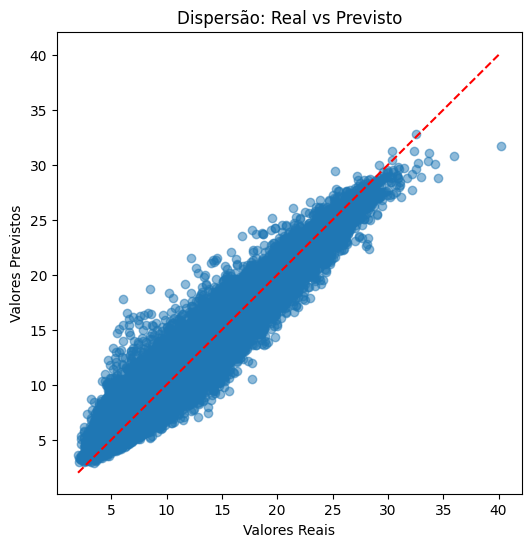

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Dispersão: Real vs Previsto')
plt.show()

In [ ]:
# --- Etapa 5: Carregando arquivo com as previsões ---

print("--- Carregando o arquivo com as previsões ---")
try:
    df_previsoes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/previsoes_eolica_goias_final.csv')
    print("Arquivo 'previsoes_eolica_goias_final.csv' carregado com sucesso.")
except FileNotFoundError:
    print("Erro: O arquivo 'previsoes_eolica_goias_final.csv' não foi encontrado.")
    print("Por favor, execute o script anterior para gerar este arquivo ou verifique o caminho.")
    exit()

--- Carregando o arquivo com as previsões ---
Arquivo 'previsoes_eolica_goias_final.csv' carregado com sucesso.


In [ ]:
# --- Etapa 6: Calculando a Média de Vento por Município ---

print("\n--- Calculando o potencial solar médio por município ---")
# Aqui os dados são agrupados por município. Para cada um, é calculada a média de vento.
# Também pegamos a primeira latitude e longitude, já que elas são constantes para cada município.
potencial_solar = df_previsoes.groupby('municipio').agg(
    radiacao_media=('VELOCIDADE_VENTO_PREDITA', 'mean'),
    lat=('lat', 'first'),
    lon=('lon', 'first')
).reset_index()


--- Calculando o potencial solar médio por município ---


In [ ]:
# --- Etapa 7: Seleciona os Municípios com Maior Potencial ---

print("--- Selecionando os municípios com maior irradiação ---")
# Ordenamos o resultado pela 'radiacao_media' em ordem decrescente e pegamos os 10 primeiros.
top_municipios = potencial_solar.sort_values(by='radiacao_media', ascending=False).head(10)

print("\nOs 10 municípios com maior potencial solar médio (MJ/m²):")
print(top_municipios.head(10))

--- Selecionando os municípios com maior irradiação ---

Os 10 municípios com maior potencial solar médio (MJ/m²):
                 municipio  radiacao_media        lat        lon
133                 Mambaí       12.199503 -14.411867 -46.067983
7    Alto Paraíso de Goiás       12.059224 -14.182639 -47.534768
56              Cavalcante       10.610675 -13.634723 -47.695683
183             Planaltina       10.419258 -15.282981 -47.751410
188                  Posse       10.244850 -14.235855 -46.440868
181            Pirenópolis        9.989857 -15.808447 -49.010858
107                Ipameri        9.983433 -17.505494 -48.054377
243     Água Fria de Goiás        9.967740 -14.906060 -47.795031
140               Mineiros        9.901329 -17.567756 -52.755093
130    Leopoldo de Bulhões        9.830031 -16.565402 -48.891359


In [ ]:
# --- Etapa 8: Gera o Mapa Interativo com Folium ---

print("\n--- Gerando o mapa interativo ---")
# Cria um mapa centrado nas coordenadas aproximadas de Goiás. Onde latitude e longitude de Goiás: -15.98, -49.86
mapa_goias = folium.Map(location=[-15.98, -49.86], zoom_start=7, tiles='OpenStreetMap')

# Adiciona um marcador para cada um dos municípios mais relevantes
for index, row in top_municipios.iterrows():
    popup_text = f"<b>Município:</b> {row['municipio']}<br><b>Radiação Média (Final):</b> {row['radiacao_media']:.2f} MJ/m²"
     # Cria o marcador e o adiciona ao mapa
    folium.Marker(
        # Coordenadas do município
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=folium.Tooltip(
            text=row['municipio'], permanent=True, direction='top',
            offset=[0, -10], style="font-weight:bold; font-size:10px;"
        )
    ).add_to(mapa_goias)
# Salva o mapa como um arquivo HTML
mapa_filename_final = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/mapa_potencial_eolica_final.html'
mapa_goias.save(mapa_filename_final)
print(f"\nMapa final salvo como '{mapa_filename_final}'.")

mapa_goias


--- Gerando o mapa interativo ---

Mapa final salvo como '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/7.Random_Forest_Grid_Search/arquivos_gerados/mapa_potencial_eolica_final.html'.
